In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Literal
import matplotlib.patches as mpatches
import seaborn as sns

In [2]:
# Set plotting style
plt.rcParams.update({
    "grid.linewidth":   0.5,
    "font.size":        10,
    "axes.titlesize":   11,
    "axes.titleweight": "bold",
})

BLUE   = "#378ADD"
TEAL   = "#1D9E75"
AMBER  = "#EF9F27"
CORAL  = "#D85A30"
PURPLE = "#7F77DD"
GRAY   = "#888780"
PALETTE = [BLUE, TEAL, AMBER, CORAL, PURPLE, GRAY,
           "#639922","#BA7517","#185FA5","#3B6D11"]

In [3]:
file_path = r"C:\Users\annad\Documents\UvAnna x VU\Data Mining\dataset_mood_smartphone.csv"
df = pd.read_csv(file_path)

In [4]:
# Add date and hour only columns 
df["time"] = pd.to_datetime(df["time"])
df["date"] = df["time"].dt.date
df["date"] = pd.to_datetime(df["date"])
df["hour"] = df["time"].dt.hour
df.head()

,Unnamed: 0,id,time,variable,value,date,hour
0,1,AS14.01,2014-02-26 13:00:00,mood,6.0,2014-02-26,13
1,2,AS14.01,2014-02-26 15:00:00,mood,6.0,2014-02-26,15
2,3,AS14.01,2014-02-26 18:00:00,mood,6.0,2014-02-26,18
3,4,AS14.01,2014-02-26 21:00:00,mood,7.0,2014-02-26,21
4,5,AS14.01,2014-02-27 09:00:00,mood,6.0,2014-02-27,9


## Exploratory Data Analysis

In [5]:
print("Number of observations x Number of columns:", df.shape)
print("Earliest timestamp:", df['time'].min())
print("Latest timestamp", df['time'].max())
print("Unique users:", df['id'].nunique())
print("Unique variables:", df['variable'].nunique())
print("Total missing values (in value column):", df['value'].isnull().sum())

Number of observations x Number of columns: (376912, 7)
Earliest timestamp: 2014-02-17 07:00:52.197000
Latest timestamp 2014-06-09 00:00:00
Unique users: 27
Unique variables: 19
Total missing values (in value column): 202


In [6]:
grouped = df.groupby("variable")["value"]
# Total count and missing count per variable
total_per_variable = grouped.count()
missing_per_variable = grouped.size() - grouped.count()
missing_pct = (missing_per_variable / (missing_per_variable + total_per_variable)) * 100

stats = grouped.describe().rename(columns={"50%": "median"})
stats["missing"] = missing_per_variable
stats["missing %"] = missing_pct.round(1).fillna(100.0)
# Add variable type based on unique values and specific variable name
stats["type"] = [
    "binary" if df.loc[df["variable"] == var, "value"].nunique(dropna=True) <= 2
    else "ordinal" if var == "mood" else "continuous"
    for var in stats.index
]
stats

,count,mean,std,min,25%,median,75%,max,missing,missing %,type
variable,,,,,,,,,,,
activity,22965.0,0.115958,0.186946,0.000,0.00000,0.021739,0.158333,1.000,0,0.0,continuous
appCat.builtin,91288.0,18.538262,415.989243,-82798.871,2.02000,4.038000,9.922000,33960.246,0,0.0,continuous
appCat.communication,74276.0,43.343792,128.912750,0.006,5.21800,16.225500,45.475750,9830.777,0,0.0,continuous
appCat.entertainment,27125.0,37.576480,262.960476,-0.011,1.33400,3.391000,14.922000,32148.677,0,0.0,continuous
appCat.finance,939.0,21.755251,39.218361,0.131,4.07200,8.026000,20.155000,355.513,0,0.0,continuous
appCat.game,813.0,128.391615,327.145246,1.003,14.14800,43.168000,123.625000,5491.793,0,0.0,continuous
appCat.office,5642.0,22.578892,449.601382,0.003,2.00400,3.106000,8.043750,32708.818,0,0.0,continuous
appCat.other,7650.0,25.810839,112.781355,0.014,7.01900,10.028000,16.829250,3892.038,0,0.0,continuous
appCat.social,19145.0,72.401906,261.551846,0.094,9.03000,28.466000,75.372000,30000.906,0,0.0,continuous


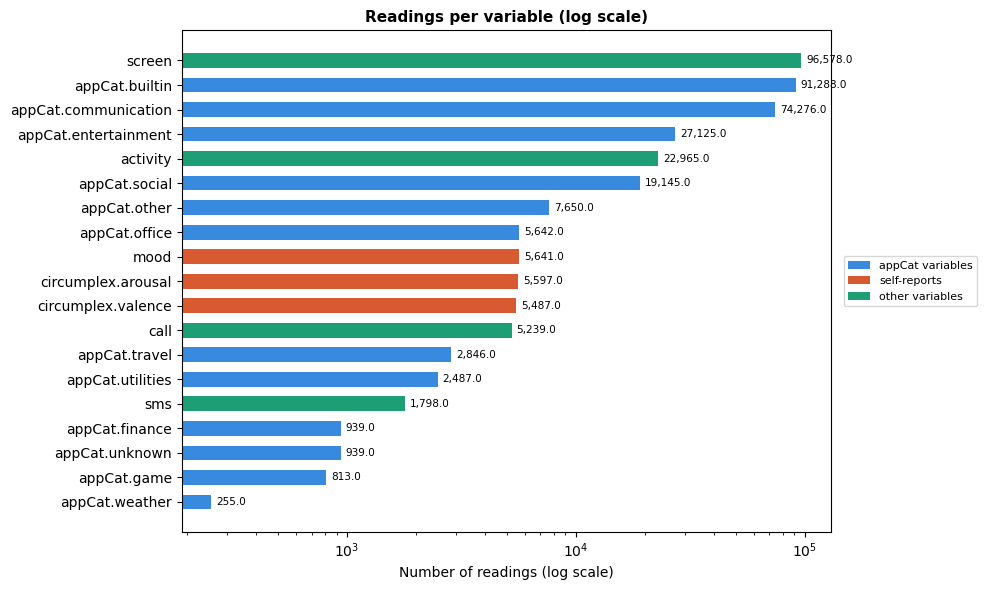

In [8]:
counts = stats["count"].sort_values(ascending=True)
colors_bar = [
    BLUE if "appCat" in v else
    CORAL if v in ("mood", "circumplex.arousal", "circumplex.valence") else
    TEAL
    for v in counts.index
]

plt.figure(figsize=(10, 6))
plt.barh(counts.index, counts.values, height=0.6, color=colors_bar)
plt.xscale("log")
plt.xlabel("Number of readings (log scale)")
plt.title("Readings per variable (log scale)")
plt.legend(
    handles=[
        mpatches.Patch(facecolor=BLUE, label="appCat variables"),
        mpatches.Patch(facecolor=CORAL, label="self-reports"),
        mpatches.Patch(facecolor=TEAL, label="other variables"),
    ],
    fontsize=8,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    frameon=True,
)
for value, variable in zip(counts.values, counts.index):
    plt.text(value * 1.05, variable, f"{value:,}", va="center", fontsize=7.5)
plt.tight_layout()
plt.show()

# Sensor data (screen, appCat) is sampled far more than self-reports (mood, arousal). Maybe table is enough to show this
# Need to understand how to handle this when we will pivot the data to wide format and have missing values for self-reports.

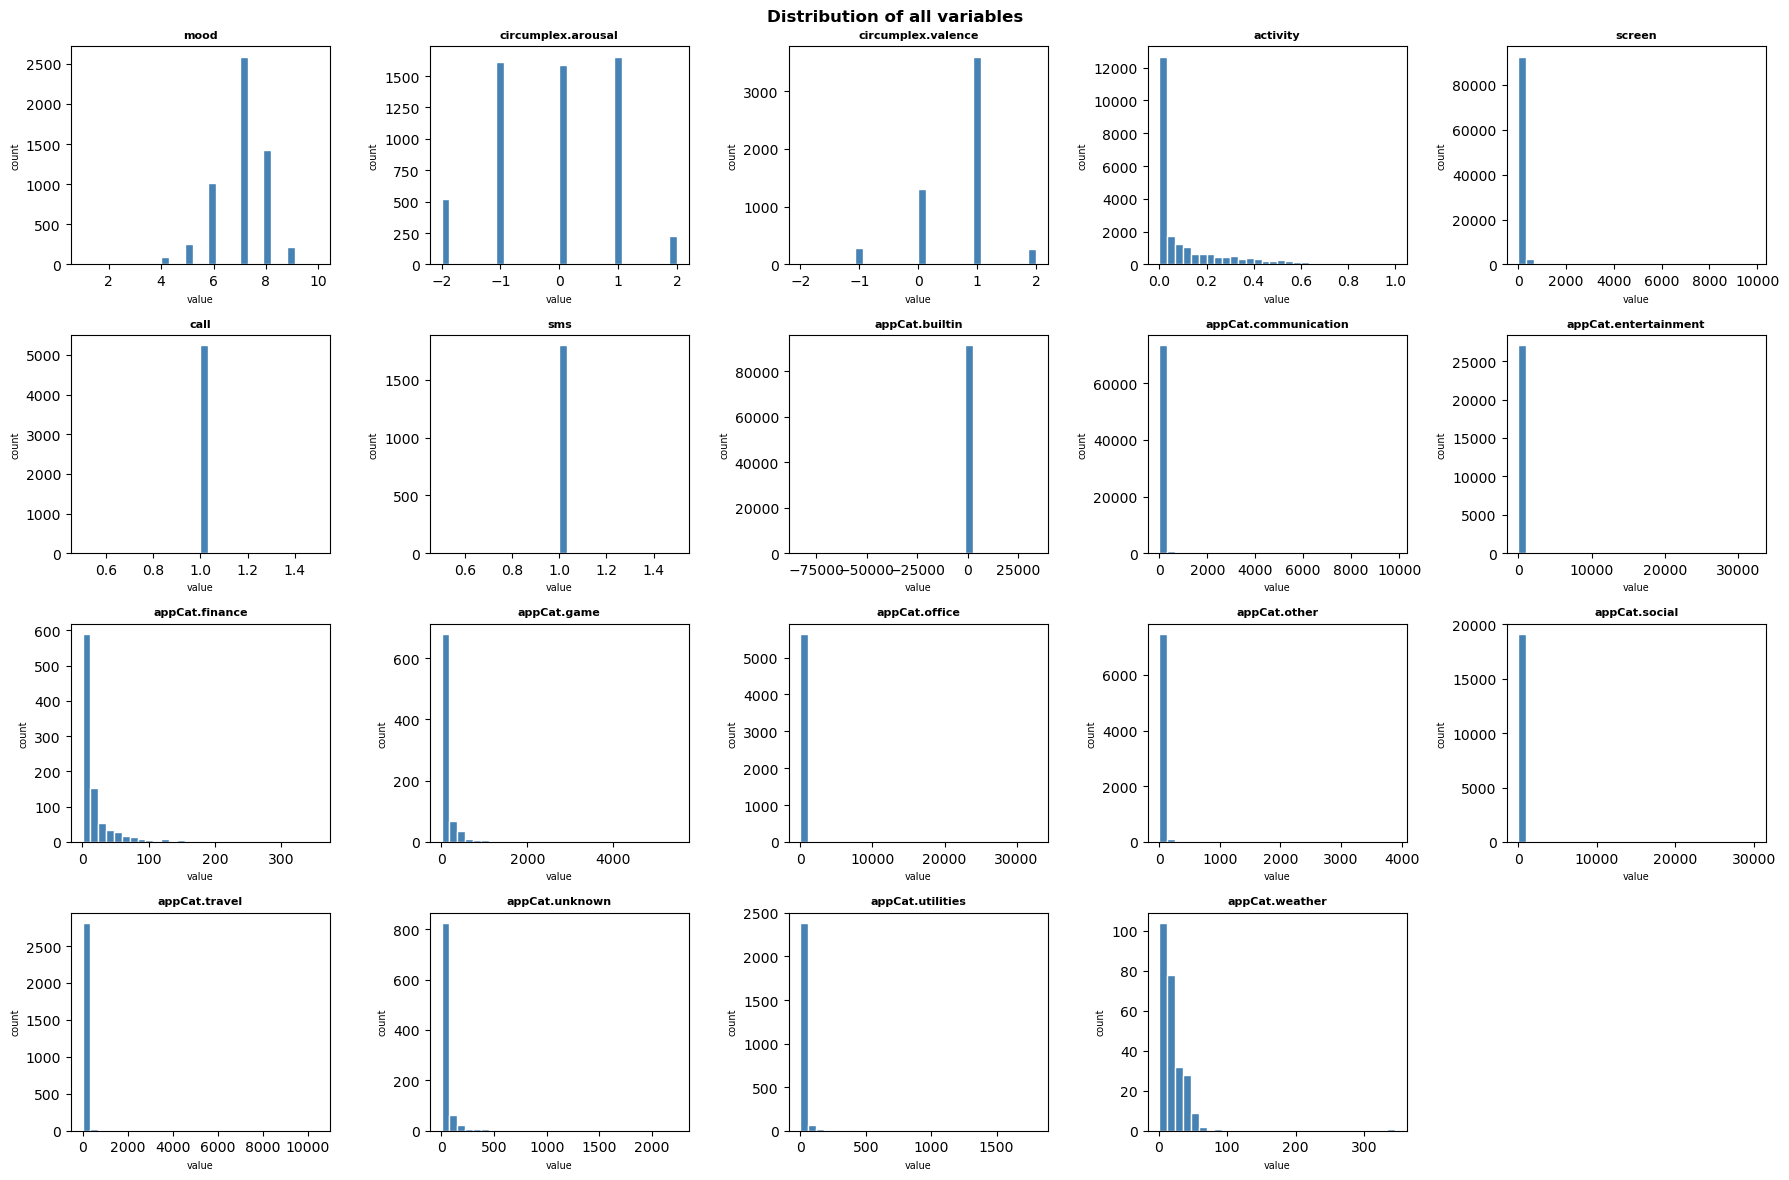

In [9]:
# Distribution of all variables (histograms)
variables = df["variable"].unique()
fig, axes = plt.subplots(4, 5, figsize=(18, 12))
 
for ax, var in zip(axes.flatten(), variables):
    values = df[df["variable"] == var]["value"].dropna()
    ax.hist(values, bins=30, color="steelblue", edgecolor="white")
    ax.set_title(var, fontsize=8)
    ax.set_xlabel("value", fontsize=7)
    ax.set_ylabel("count", fontsize=7)
 
# hide the last empty subplot
axes.flatten()[-1].set_visible(False)
 
plt.suptitle("Distribution of all variables", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


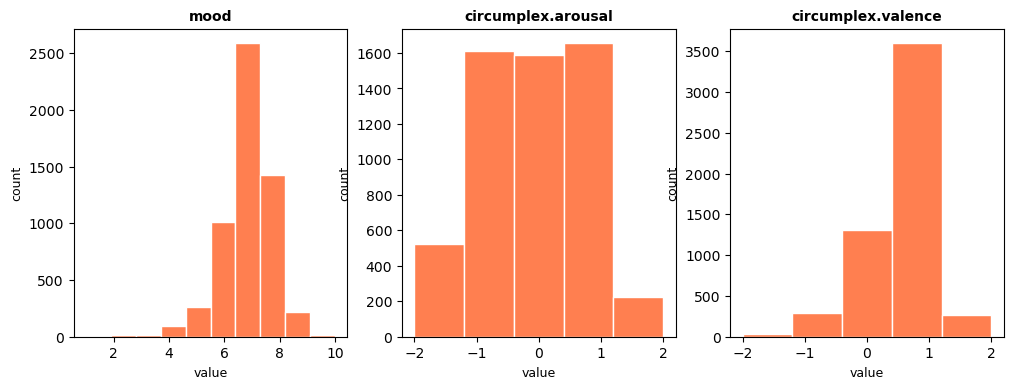

In [ ]:
# Focus on mood variables
mood_vars = ["mood", "circumplex.arousal", "circumplex.valence"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4)) 
for ax, var in zip(axes, mood_vars):
    values = df[df["variable"] == var]["value"].dropna()
    if var == "mood":
        bins = np.arange(1, 11) - 0.5
        ax.hist(values, bins=10, color="coral", edgecolor="white")
    else:
        bins = np.arange(-2, 3) - 0.5
        ax.hist(values, bins=5, color="coral", edgecolor="white")
    ax.set_title(var, fontsize=10)
    ax.set_xlabel("value", fontsize=9)
    ax.set_ylabel("count", fontsize=9)

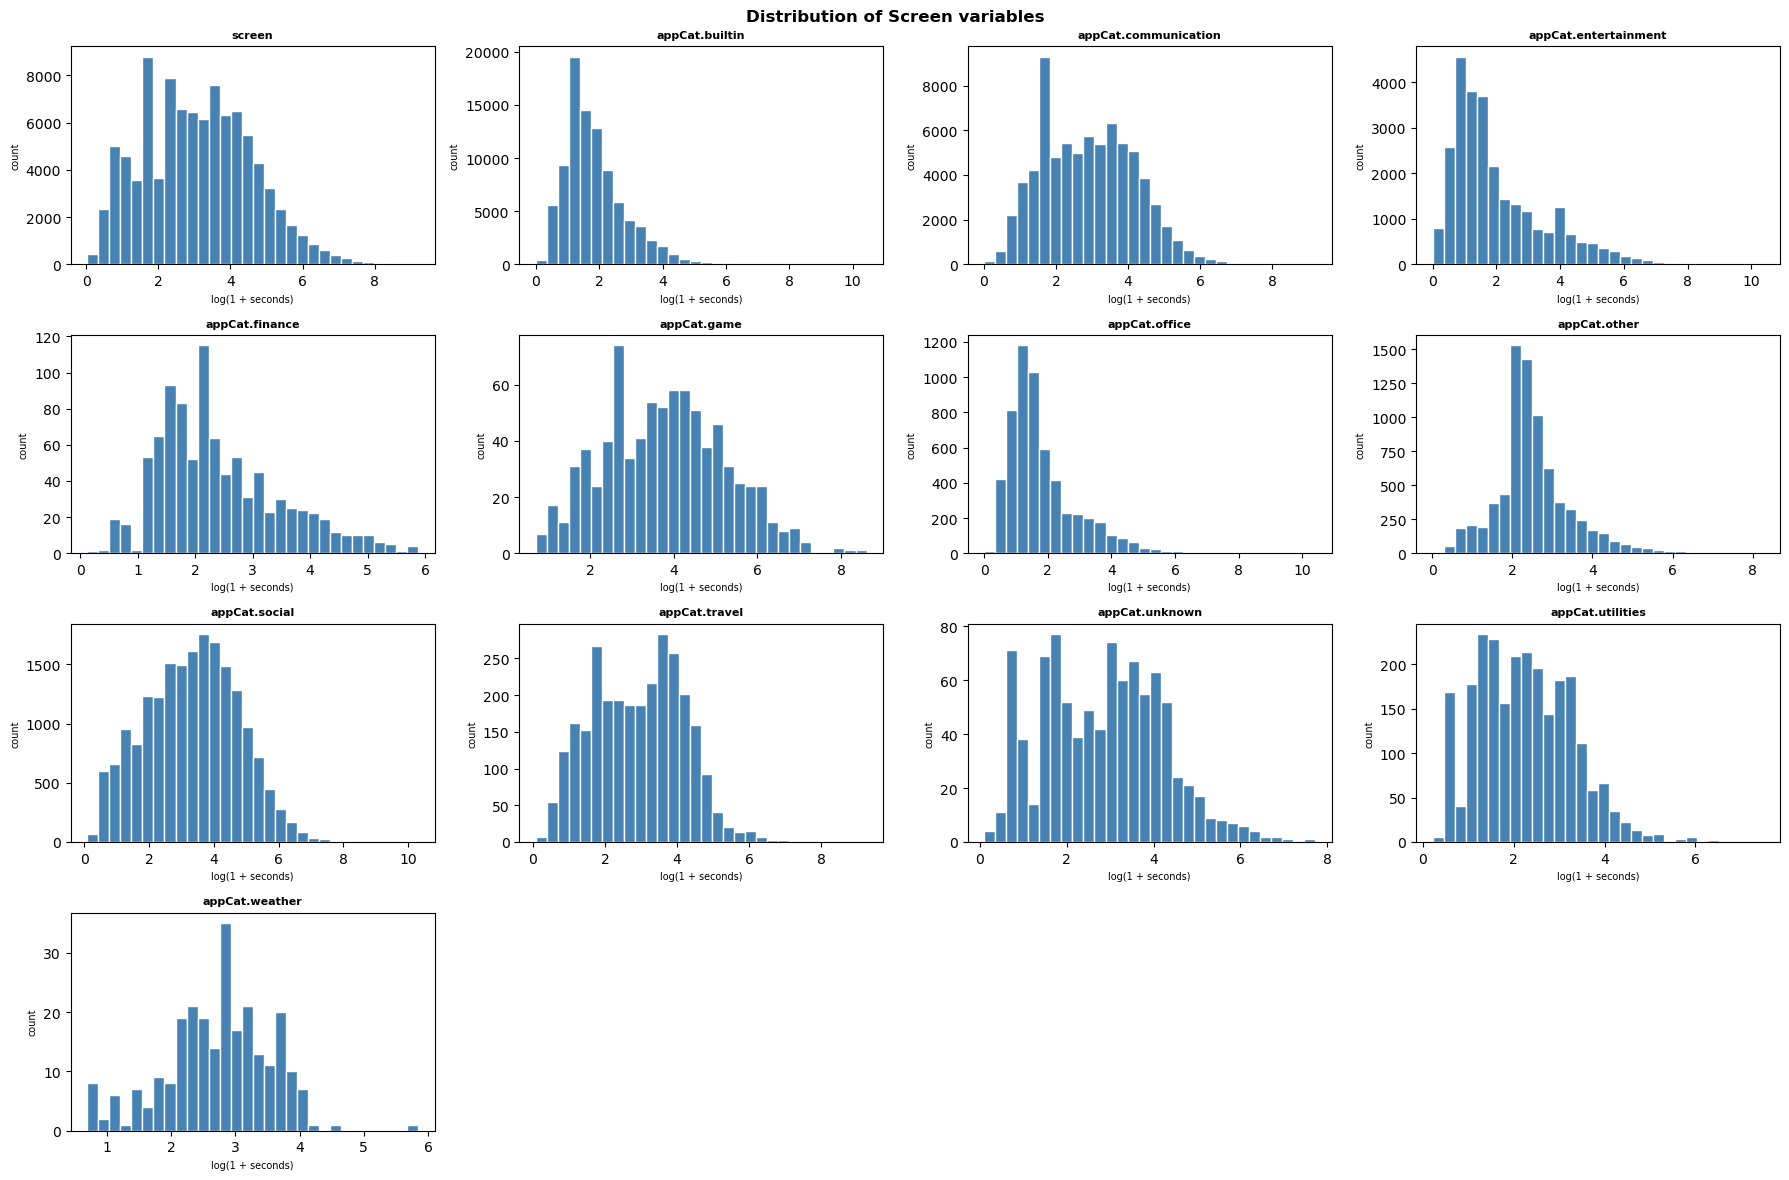

In [10]:
# Focus on screen and app category variables
# highly skewed distributions with many zeros, so we can log-transform the values
duration_vars = ["screen", "appCat.builtin", "appCat.communication",
                 "appCat.entertainment", "appCat.finance", "appCat.game",
                 "appCat.office", "appCat.other", "appCat.social",
                 "appCat.travel", "appCat.unknown", "appCat.utilities",
                 "appCat.weather"]
fig, axes = plt.subplots(4, 4, figsize=(18, 12))
 
for ax, var in zip(axes.flatten(), duration_vars):
    if var in duration_vars:
        values = df[df["variable"] == var]["value"].dropna()
        values = np.log1p(values.clip(lower=0)) # to avoid log of negative values + log(0) issues
        ax.set_xlabel("log(1 + seconds)", fontsize=7)
        ax.hist(values, bins=30, color="steelblue", edgecolor="white")
        ax.set_title(var, fontsize=8)
        ax.set_ylabel("count", fontsize=7)

axes.flatten()[-1].set_visible(False)
axes.flatten()[-2].set_visible(False)
axes.flatten()[-3].set_visible(False)
 
plt.suptitle("Distribution of Screen variables", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

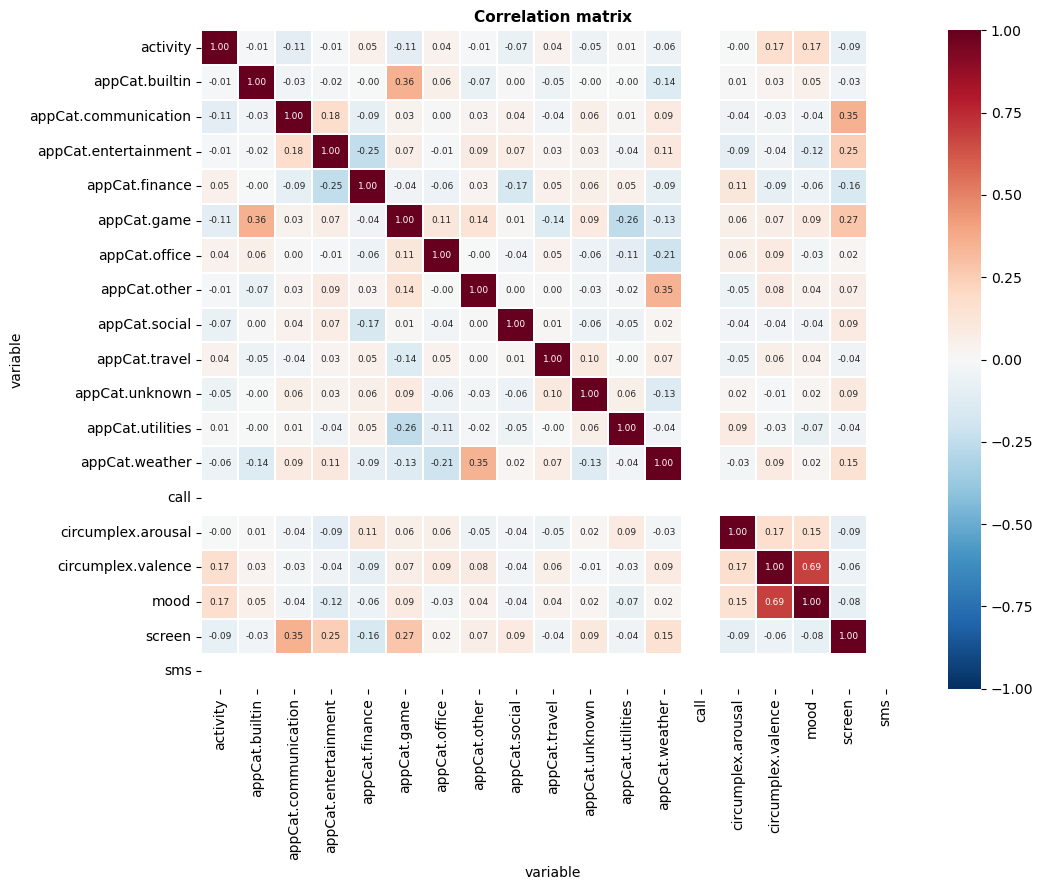

In [ ]:
# correlation matrix for numeric variables in long-format data (**Check**)
correlation_data = (
    df.groupby(["id", "date", "variable"])["value"]
      .mean() 
      .unstack("variable")
)

correlation_data = correlation_data.dropna(axis=1, how="all")
correlation_matrix = correlation_data.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    annot_kws={"size": 6.5},
    ax=ax,
)
ax.set_title("Correlation matrix", fontweight="bold")
plt.tight_layout()
plt.show()

# high correlation between mood and valance

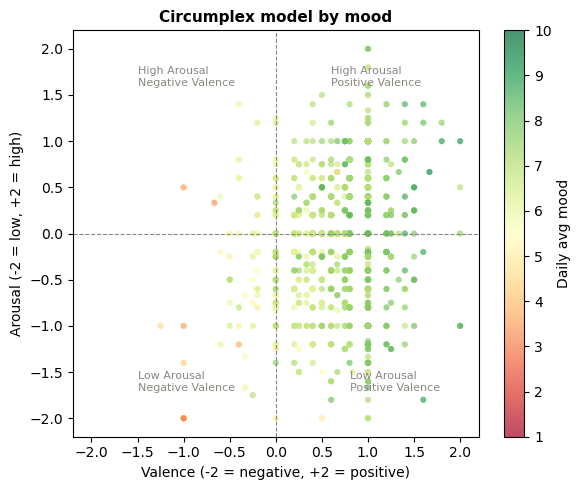

In [13]:
# Check valence and arousal correlation with mood 
circ = (df[df["variable"].isin(["circumplex.arousal","circumplex.valence","mood"])]
        .groupby(["id","date","variable"])["value"].mean()
        .unstack("variable").reset_index().dropna())
 
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(circ["circumplex.valence"], circ["circumplex.arousal"],
                c=circ["mood"], cmap="RdYlGn", vmin=1, vmax=10,
                alpha=0.7, linewidths=0, s = 20)
plt.colorbar(sc, ax=ax, label="Daily avg mood")
plt.axhline(0, color=GRAY, lw=0.8, ls="--")
plt.axvline(0, color=GRAY, lw=0.8, ls="--")
plt.ylim(-2.2, 2.2)
plt.xlim(-2.2, 2.2)
plt.xlabel("Valence (-2 = negative, +2 = positive)")
plt.ylabel("Arousal (-2 = low, +2 = high)")
plt.title("Circumplex model by mood")
# Quadrant labels
for x, y, lbl in [(.6, 1.6, "High Arousal\nPositive Valence"), (.8, -1.7, "Low Arousal\nPositive Valence"),
                   (-1.5, 1.6, "High Arousal\nNegative Valence"), (-1.5, -1.7, "Low Arousal\nNegative Valence")]:
    plt.text(x, y, lbl, fontsize=8, color=GRAY)
plt.tight_layout()
plt.show()

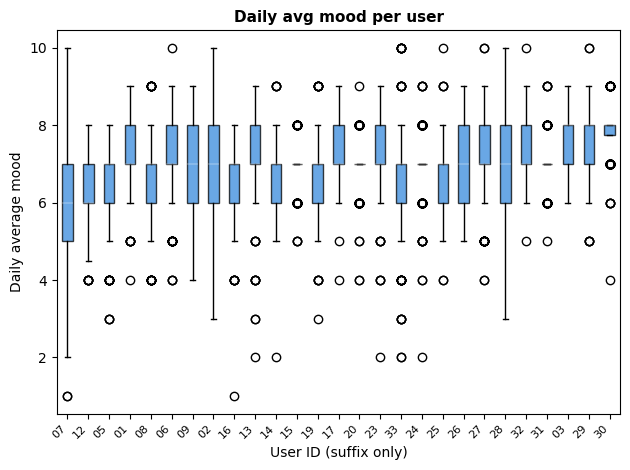

In [14]:
## Other plots for exploration (e.g., usage patterns by hour of day, mood over time, etc.)
# Distribution of mood ratings per user
mood = df[df["variable"] == "mood"][["id", "time", "value"]].copy()
# daily averages per user
daily_mood = mood.groupby(["id", "time"])["value"].mean().reset_index()
user_order = (daily_mood.groupby("id")["value"]
              .median().sort_values().index.tolist())
data_per_user = [daily_mood[daily_mood["id"] == u]["value"].values
                 for u in user_order]
bp = plt.boxplot(data_per_user, vert=True, patch_artist=True, medianprops=dict(color="white", lw=0.3))
for patch in bp["boxes"]:
    patch.set_facecolor(BLUE)
    patch.set_alpha(0.75)
ax = plt.gca()
ax.set_xticks(range(1, len(user_order) + 1))
ax.set_xticklabels([u.replace("AS14.", "") for u in user_order], rotation=45, ha="right", fontsize=8)
plt.xlabel("User ID (suffix only)")
plt.ylabel("Daily average mood")
plt.title("Daily avg mood per user")
plt.tight_layout()
plt.show()


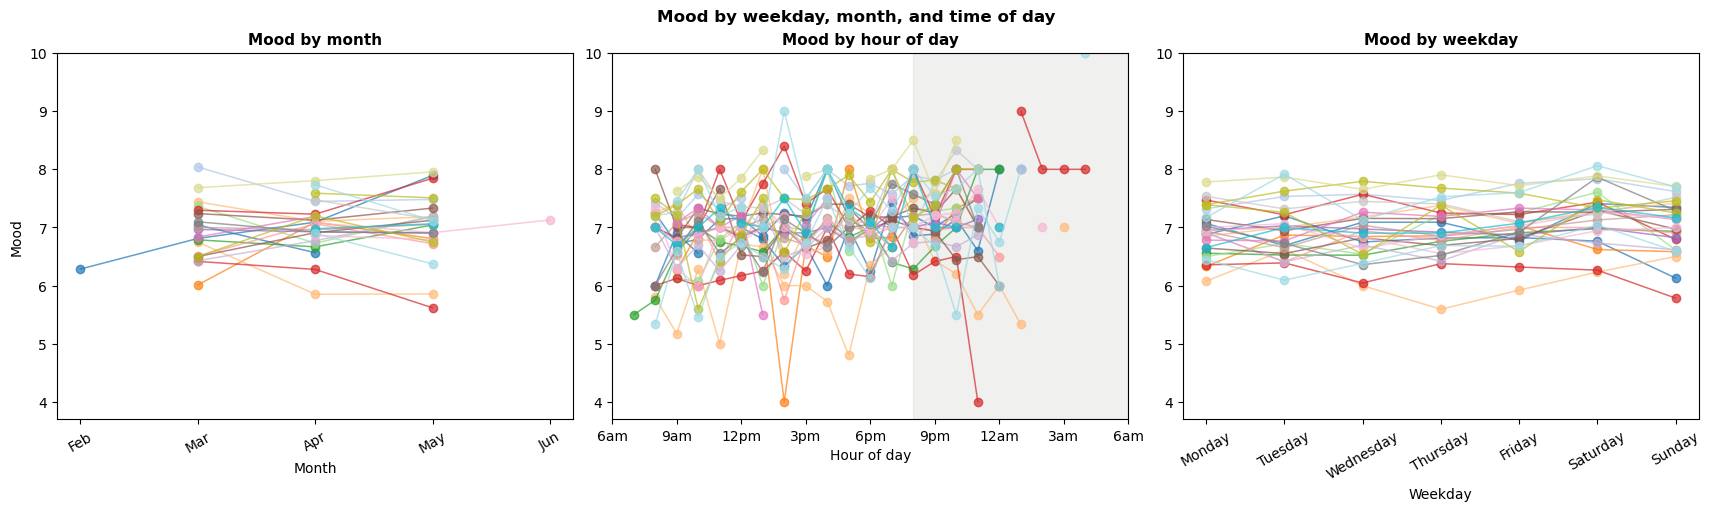

In [20]:
# Check mood patterns by weekday, month, and hour of day (line plots)
all_users = sorted(df.loc[df["variable"] == "mood", "id"].dropna().unique())
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
month_order = sorted(df.loc[df["variable"] == "mood", "time"].dt.month.dropna().unique())
month_labels = [pd.Timestamp(month=month, day=1, year=2000).strftime("%b") for month in month_order]
hour_order = list(range(6, 30))
user_colors = dict(zip(all_users, plt.cm.tab20(np.linspace(0, 1, max(len(all_users), 1)))))
 
fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
 
for uid in all_users:
    user_mood = df[(df["id"] == uid) & (df["variable"] == "mood")].copy()
    user_mood["weekday"] = user_mood["time"].dt.day_name()
    user_mood["month"] = user_mood["time"].dt.month
    user_mood["hour"] = user_mood["time"].dt.hour
 
    weekday_mood = user_mood.groupby("weekday")["value"].mean().reindex(weekday_order)
    month_mood = user_mood.groupby("month")["value"].mean().reindex(month_order)
    hour_mood = user_mood.groupby("hour")["value"].mean().reindex(range(24))
    hour_mood = pd.concat([hour_mood.loc[6:23], hour_mood.loc[0:5]])
 
    axes[0].plot(month_order, month_mood.values, "-o", color=user_colors[uid], lw=1.1, alpha=0.7)
    axes[1].plot(hour_order, hour_mood.values, "-o", color=user_colors[uid], lw=1.1, alpha=0.7)
    axes[2].plot(weekday_order, weekday_mood.values, "-o", color=user_colors[uid], lw=1.1, alpha=0.7)
 
axes[0].set_title("Mood by month")
axes[1].set_title("Mood by hour of day")
axes[2].set_title("Mood by weekday")
 
axes[0].set_ylabel("Mood")
axes[0].set_ylim(3.7, 10)
axes[1].set_ylim(3.7, 10)
axes[2].set_ylim(3.7, 10)
 

axes[0].set_xticks(month_order)
axes[0].set_xticklabels(month_labels, rotation=30)
axes[1].set_xticks([6, 9, 12, 15, 18, 21, 24, 27, 30])
axes[1].set_xticklabels(["6am", "9am", "12pm", "3pm", "6pm", "9pm", "12am", "3am", "6am"])
axes[1].axvspan(20, 30, color=GRAY, alpha=0.12)
axes[1].set_xlim(6, 30)
axes[2].tick_params(axis="x", rotation=30)

axes[0].set_xlabel("Month")
axes[1].set_xlabel("Hour of day")
axes[2].set_xlabel("Weekday")
 
fig.suptitle("Mood by weekday, month, and time of day", fontweight="bold")
plt.show()

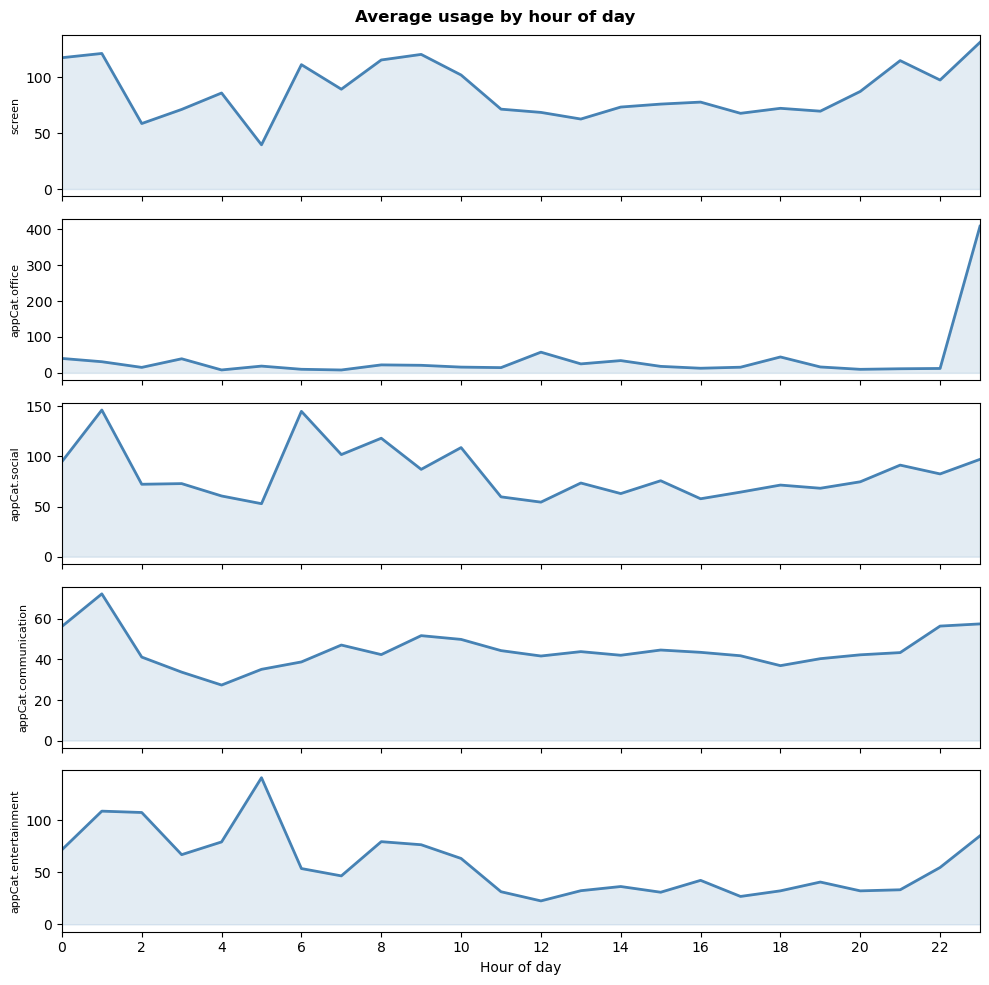

In [22]:
usage_vars = ["screen", "appCat.office", "appCat.social",
                "appCat.communication", "appCat.entertainment"]
 
fig, axes = plt.subplots(len(usage_vars), 1, figsize=(10, 10), sharex=True)
 
for ax, var in zip(axes, usage_vars):
    hourly = (
        df[df["variable"] == var]
        .groupby(["date", "hour"])["value"]
        .mean()
        .groupby("hour")
        .mean()
        .reindex(range(24))
    )
    ax.plot(hourly.index, hourly.values, color="steelblue", lw=2)
    ax.fill_between(hourly.index, hourly.values, alpha=0.15, color="steelblue")
    ax.set_ylabel(var, fontsize=8)
    ax.set_xlim(0, 23)
    ax.set_xticks(range(0, 24, 2))
 
axes[-1].set_xlabel("Hour of day")
fig.suptitle("Average usage by hour of day", fontweight="bold")
plt.tight_layout()

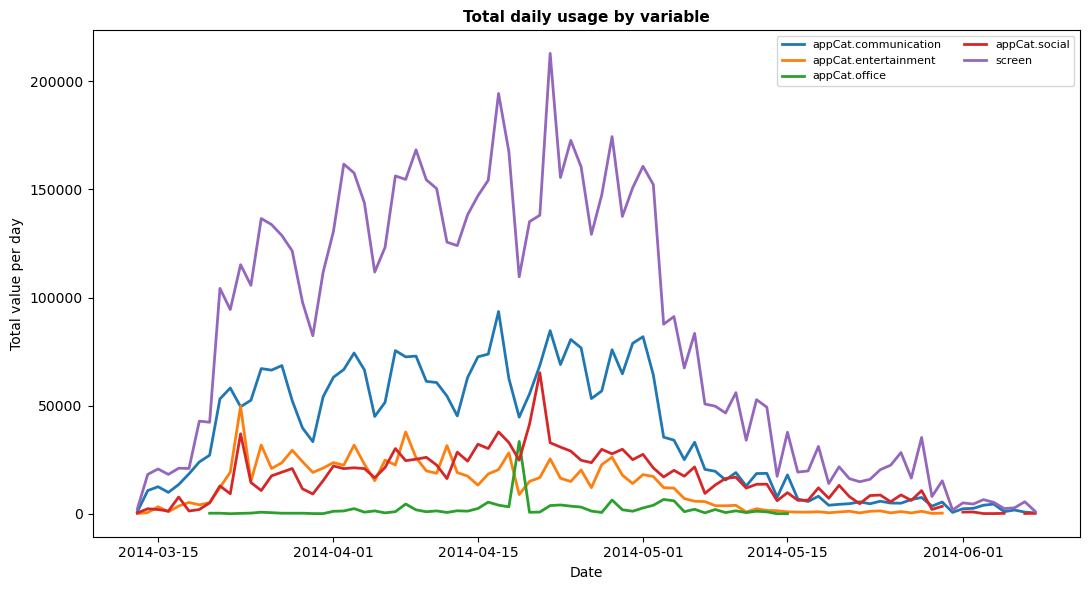

In [23]:
# Total daily usage per variable
daily_usage = (
    df[df["variable"].isin(usage_vars)]
    .groupby(["date", "variable"])["value"]
    .sum()
    .unstack("variable")
)

plt.figure(figsize=(11, 6))
for col in daily_usage.columns:
    plt.plot(daily_usage.index, daily_usage[col], linewidth=2, label=col)

plt.title("Total daily usage by variable", fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Total value per day")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Notes

- data is between 02/2014 until 06/2014, but only for 2 people feb and june are included
- appCat.builtin and entertainment have min negative values: remove or clip?
- usage times have extreme outliers (e.g. screen max is approx 2.7 hours, social is 8h and office is 9h)
- call and sms mark events
- mood mean = 7.0, std = 1.0
- circumplex.valence mean = 0.69 (positive), arousal mean = -0.10 (calm)
 